# RL Agent for Game Playing

## 📚 Learning Objectives

By completing this notebook, you will:
- Build a game-playing RL agent
- Train and evaluate in a game environment

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 5**.

---


## Lesson Brief

This lesson uses a simple game to show why games are one of the clearest environments for reinforcement learning.

Students will see how state, action, reward, and repeated episodes naturally appear in game settings.

Why this matters: game-playing examples make RL concrete and easy to visualize.

This lesson helps students connect abstract RL ideas to visible outcomes.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Turn-based environment: players act one after another.
- Opponent effect: another player changes the dynamics.
- Win condition: what counts as success.
- Strategy learning: improving through repeated play.

### Quick Check
- Why are games useful for learning RL?
- How do state, action, and reward appear in the game?
- What changes when another player is involved?

### Common Mistakes
- Focusing on game rules but missing RL structure.
- Assuming learning happens instantly.
- Ignoring how the opponent changes the problem.


# RL Agent for Game Playing
## AIAT 123 - Reinforcement Learning

## Learning Objectives

- Build an RL-style agent for game playing
- Connect state, action, and reward to a board game
- See how repeated episodes support learning in games
- Evaluate agent performance against a simple opponent

## Real-World Context

Game AI development, strategy games, and competitive AI.

**Industry Impact**: Powers game AI in chess, Go, and video games.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

import numpy as np
print('✅ Setup complete!')

✅ Setup complete!


## Part 1: Simple Game Environment (Tic-Tac-Toe)


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [2]:
# Model definition: this class packages one core RL concept into a reusable object.
# Read its state, methods, and update rules together so the algorithm feels concrete.

class TicTacToe:
    """Simple Tic-Tac-Toe game environment."""
    def __init__(self):
        self.board = np.zeros((3, 3), dtype=int)

    def reset(self):
        self.board[:] = 0
        return self.board.copy()

    def available_actions(self):
        return [(r, c) for r in range(3) for c in range(3) if self.board[r, c] == 0]

    def step(self, action, player=1):
        r, c = action
        if self.board[r, c] != 0:
            return self.board.copy(), -5, True, {"invalid": True}
        self.board[r, c] = player
        reward = 1 if self.check_winner(player) else 0
        done = reward == 1 or len(self.available_actions()) == 0
        return self.board.copy(), reward, done, {"invalid": False}

    def check_winner(self, player):
        rows = np.any(np.sum(self.board == player, axis=1) == 3)
        cols = np.any(np.sum(self.board == player, axis=0) == 3)
        diag1 = np.sum(np.diag(self.board == player)) == 3
        diag2 = np.sum(np.diag(np.fliplr(self.board == player))) == 3
        return rows or cols or diag1 or diag2

## Part 2: Q-Learning Agent


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [3]:
# Model definition: this class packages one core RL concept into a reusable object.
# Read its state, methods, and update rules together so the algorithm feels concrete.

class QLearningAgent:
    """Minimal Q-learning agent for demonstration only."""
    def __init__(self, learning_rate=0.1, gamma=0.95, epsilon=0.1):
        self.learning_rate = learning_rate
        self.gamma = gamma
        self.epsilon = epsilon
        self.q = {}

    def key(self, board):
        return tuple(board.flatten())

    def select_action(self, env):
        actions = env.available_actions()
        if np.random.rand() < self.epsilon:
            return actions[np.random.randint(len(actions))]
        state_key = self.key(env.board)
        values = [self.q.get((state_key, action), 0.0) for action in actions]
        return actions[int(np.argmax(values))]


env = TicTacToe()
agent = QLearningAgent()
state = env.reset()
action = agent.select_action(env)
print("Selected opening action:", action)

Selected opening action: (0, 0)


## Real-World Applications

- **Chess/Go**: DeepMind AlphaZero
- **Video Games**: Dota 2, StarCraft II
- **Board Games**: Tic-Tac-Toe, Connect 4, Checkers
- **Puzzle Games**: Rubik's Cube solving

### Why this lesson matters

Games are often the cleanest place to understand RL because the rules are clear,
episodes reset easily, and success is easy to observe.

## Worked Example: Why Games Are Good RL Testbeds

Games are useful in RL because they usually provide:
- clear rules
- a known action space
- easy reset between episodes
- a visible success condition

Below, you will compare a simple game-playing strategy against a random opponent.
The point is not to build AlphaZero here. The point is to see how state,
actions, rewards, and repeated episodes naturally fit the RL setup.

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [4]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

def winning_move(env, player):
    for action in env.available_actions():
        board_backup = env.board.copy()
        _, reward, done, _ = env.step(action, player=player)
        env.board = board_backup
        if done and reward == 1:
            return action
    return None


def center_then_random(env):
    if env.board[1, 1] == 0:
        return (1, 1)
    actions = env.available_actions()
    return actions[np.random.randint(len(actions))]


def play_game(policy_player=1):
    env = TicTacToe()
    env.reset()
    current_player = 1

    while True:
        if current_player == policy_player:
            action = winning_move(env, current_player)
            if action is None:
                action = center_then_random(env)
        else:
            action = env.available_actions()[np.random.randint(len(env.available_actions()))]

        _, reward, done, _ = env.step(action, player=current_player)
        if done:
            if reward == 1:
                return current_player
            return 0
        current_player = 2 if current_player == 1 else 1


results = {1: 0, 2: 0, 0: 0}
for _ in range(200):
    winner = play_game(policy_player=1)
    results[winner] += 1

print("Results over 200 games:")
print(" Policy player wins:", results[1])
print(" Random opponent wins:", results[2])
print(" Draws:", results[0])

print("\nTeaching point:")
print("Games are useful RL environments because the agent can play many episodes,")
print("observe wins and losses, and gradually improve its policy from repeated experience.")

Results over 200 games:
 Policy player wins: 183
 Random opponent wins: 9
 Draws: 8

Teaching point:
Games are useful RL environments because the agent can play many episodes,
observe wins and losses, and gradually improve its policy from repeated experience.


## 📚 References & Further Reading

**Books:**
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

**Papers:**
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

**State-of-the-Art:** OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.

## Summary

This notebook showed why games are a natural RL application area:

- the state is the board configuration
- actions are legal moves
- rewards can represent wins, losses, or draws
- the environment resets cleanly for repeated practice

### Main takeaway

Game-playing problems make RL ideas concrete because students can easily see how
better decisions lead to better outcomes over many episodes.

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


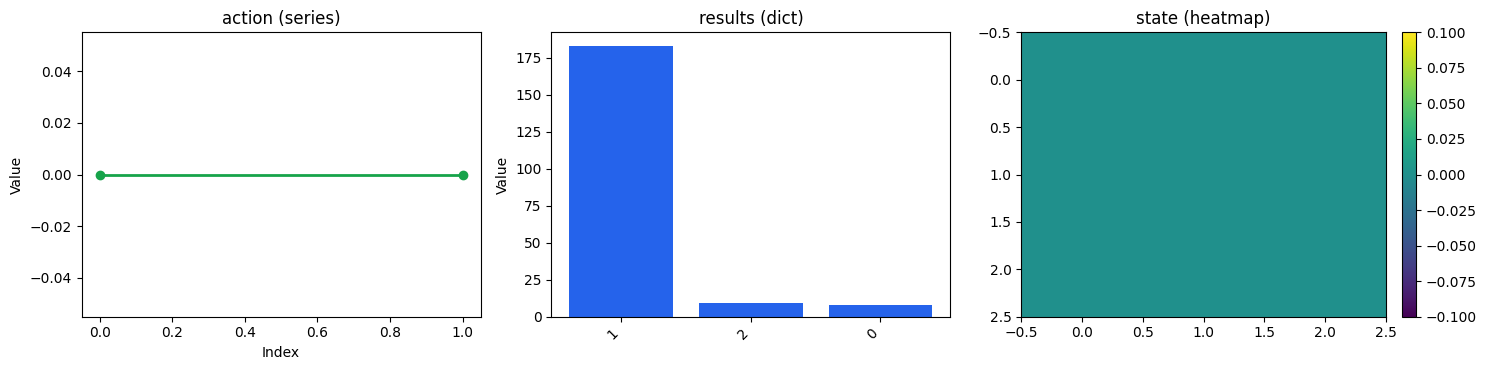

In [5]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
import numbers
import numpy as np
import matplotlib.pyplot as plt

def _is_number(value):
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

def _as_numeric_dict(value):
    if not isinstance(value, dict) or not value or len(value) > 12:
        return None
    converted = []
    for item in value.values():
        if not _is_number(item):
            return None
        converted.append(float(item))
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

def _as_numeric_array(value, dims):
    try:
        array = np.asarray(value, dtype=float)
    except Exception:
        return None
    if array.ndim != dims:
        return None
    if dims == 1 and not (2 <= array.size <= 200):
        return None
    if dims == 2 and array.size > 400:
        return None
    return array

priority_names = [
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
]

skip_names = {"np", "plt", "numbers", "math"}
candidates = []
seen = set()
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

for name in search_space:
    if name in seen or name not in globals() or name in skip_names:
        continue
    seen.add(name)
    value = globals()[name]

    dict_payload = _as_numeric_dict(value)
    if dict_payload is not None:
        candidates.append(("dict", name, dict_payload))
        if len(candidates) == 3:
            break
        continue

    array_2d = _as_numeric_array(value, 2)
    if array_2d is not None:
        candidates.append(("heatmap", name, array_2d))
        if len(candidates) == 3:
            break
        continue

    array_1d = _as_numeric_array(value, 1)
    if array_1d is not None:
        candidates.append(("line", name, array_1d))
        if len(candidates) == 3:
            break

if not candidates:
    summary = {
        "functions": sum(callable(value) for value in globals().values()),
        "classes": sum(isinstance(value, type) for value in globals().values()),
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    }
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    ax.set_title("Notebook artifact summary")
    ax.set_ylabel("Count")
    for idx, value in enumerate(summary.values()):
        ax.text(idx, value + 0.05, str(value), ha="center")
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    if len(candidates) == 1:
        axes = [axes]

    for ax, (kind, name, payload) in zip(axes, candidates):
        if kind == "dict":
            labels, values = payload
            ax.bar(range(len(values)), values, color="#2563eb")
            ax.set_xticks(range(len(values)))
            ax.set_xticklabels(labels, rotation=45, ha="right")
            ax.set_title(f"{name} (dict)")
            ax.set_ylabel("Value")
        elif kind == "line":
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            ax.set_title(f"{name} (series)")
            ax.set_xlabel("Index")
            ax.set_ylabel("Value")
        else:
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            ax.set_title(f"{name} (heatmap)")
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Games are useful RL testbeds because actions, feedback, and consequences are easy to observe and discuss clearly.

**If students remember one idea:** Game-playing examples help students see decision quality across many repeated interactions, which is central to RL thinking.

**Quick check before moving on:**
- Can you explain why games are good environments for testing RL ideas?
- Can you describe what makes a game strategy better than a short-term greedy move?

**Bridge to the next step:** After games, students can transfer the same sequential-decision thinking to resource optimization problems.
